# Lines, vector fields and streamlines

Three ways to draw directed or linear geometry, all from **real data**:

- `lines()` — elevation **contours** of the real Grand Canyon DEM, as 3-D polylines coloured by height.
- `vectors()` — the DEM's **downslope flow field** (from pyramids `slope`/`aspect`) as arrow glyphs.
- `streamlines()` — flow through the gradient of the real **SoilGrids** soil-carbon cube.

*DEM: Copernicus WorldDEM-30 © DLR/Airbus, provided under Copernicus by the EU/ESA. Soil: SoilGrids 2.0 ©
ISRIC — World Soil Information, CC-BY-4.0 (Poggio et al. 2021).*

---
*Data.* All layers below are built from **real data downloaded with
[earthlens](https://github.com/serapeum-org/earthlens)** and committed as small fixtures under
`examples/data/`; vector and 3-D layers are derived from those real rasters through **pyramids** (the GIS
engine), so nothing here is synthetic. Attributions are given per dataset.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

import pyramids  # import first: bootstraps pyramids' vendored GDAL
from pyramids.dataset import Dataset
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'real_dem_mont_blanc.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

## `lines()` — real elevation contours, coloured by height

`pyramids` extracts contour `LineString`s from the Grand Canyon DEM; `lines()` draws them coloured by their `elev` attribute.

contour columns: ['id', 'elev', 'geometry']


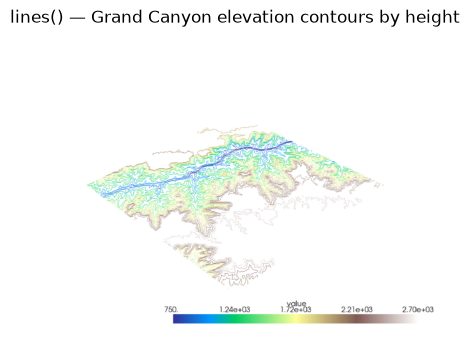

In [2]:
dem = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif'))
contours = dem.contour(interval=150)       # a FeatureCollection of elevation LineStrings (an 'elev' column)
print('contour columns:', list(contours.columns))
scene = Scene3D(off_screen=True)
scene.lines(contours, column='elev', cmap='terrain', width=2.0)
scene.view('isometric')
show(scene, 'lines() — Grand Canyon elevation contours by height')
scene.close()

## `vectors()` — the real downslope flow field

`slope` (magnitude) and `aspect` (direction) give a downhill vector at every cell; the arrows sit on the terrain (`z` = elevation).

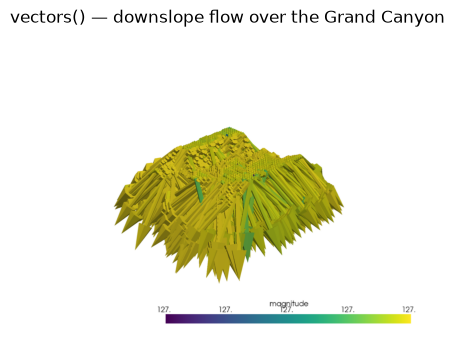

In [3]:
dem_c = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif')).resample(0.01, method='bilinear')
elev = np.asarray(dem_c.read_array(), dtype=float)
elev = elev[0] if elev.ndim == 3 else elev
slope = np.asarray(dem_c.slope(units='degrees'), dtype=float)
aspect = np.asarray(dem_c.aspect(), dtype=float)
gt = dem_c.geotransform
ny, nx = elev.shape
X, Y = np.meshgrid(gt[0] + (np.arange(nx) + 0.5) * gt[1], gt[3] + (np.arange(ny) + 0.5) * gt[5])
ok = np.isfinite(elev) & np.isfinite(slope) & np.isfinite(aspect)
a = np.deg2rad(aspect); mag = np.clip(slope, 0, None)
vx, vy, vz = np.sin(a) * mag, -np.cos(a) * mag, -mag           # point downhill
extent = max(np.ptp(X), np.ptp(Y))
z = (elev - np.nanmin(elev)); z = z / np.nanmax(z) * 0.3 * extent
pts = np.column_stack([X[ok], Y[ok], z[ok]])
vecs = np.column_stack([vx[ok], vy[ok], vz[ok]])
scene = Scene3D(off_screen=True)
scene.vectors(pts, vecs, factor=0.002, cmap='viridis')
scene.view('isometric')
show(scene, 'vectors() — downslope flow over the Grand Canyon')
scene.close()

## `streamlines()` — flow through a real 3-D field

The SoilGrids soil-organic-carbon cube (six depths) is upsampled in `z` and its gradient taken, giving a real `(nz, ny, nx, 3)` field; `streamlines()` integrates streamers coloured by speed.

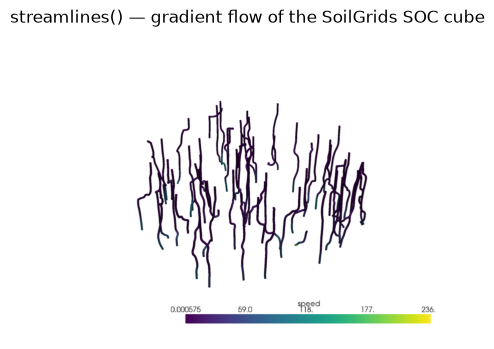

In [4]:
from scipy.ndimage import zoom
cube = np.asarray(Dataset.read_file(str(DATA / 'soilgrids_soc.tif')).read_array(), dtype=float)  # (6 depths, ny, nx)
cube = np.nan_to_num(cube, nan=float(np.nanmin(cube)))
cube = zoom(cube, (6, 1, 1), order=1)                               # give the thin depth axis room
gz, gy, gx = np.gradient(cube)
field = np.stack([gx, gy, gz], axis=-1)                             # (nz, ny, nx, 3)
scene = Scene3D(off_screen=True)
scene.streamlines(field, n_points=120, tube_radius=0.4, cmap='viridis')
scene.view('isometric')
show(scene, 'streamlines() — gradient flow of the SoilGrids SOC cube')
scene.close()